# Clustering of Buffalo Milk Production Data

Unsupervised clustering of the processed test-day records (`After_Processing.csv`).

Clustering is performed at **three levels** with **three methods** each:

| Level | Unit | Idea |
|-------|------|------|
| 1 | Per animal | Group buffaloes into lifetime production profiles |
| 2 | Per lactation | Group `(Animal_ID, parity)` lactations |
| 3 | Per test-day record | Group individual records (sampled for tractability) |

Methods: **K-Means** (with elbow + silhouette), **Hierarchical / Agglomerative** (with dendrogram), and **DBSCAN** (with k-distance eps selection). Each level is visualised with a 2-D PCA scatter and profiled by cluster means.

This notebook only *reads* `../Thesis_Data/Final_Data/After_Processing.csv`; it does not modify any other file.

In [2]:
import os

# ---- Parallelism config ----
# Use all CPU cores minus a reserve. On this 8-core machine the reserve is
# clamped so at least 1 core is used; on a big server set RESERVE_CORES = 10.
RESERVE_CORES = 20
N_JOBS = max(1, (os.cpu_count() or 1) - RESERVE_CORES)

# Let KMeans / numpy BLAS use the same number of threads (set BEFORE importing numpy).
# OpenBLAS is precompiled with a max thread count (often 64); requesting more
# triggers the "precompiled NUM_THREADS exceeded" warning, so cap the BLAS threads.
BLAS_THREADS = min(N_JOBS, 64)
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_v] = str(BLAS_THREADS)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
SIL_SAMPLE = 50000   # silhouette is O(n^2) -> always score on at most this many points
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(f'Using N_JOBS={N_JOBS} of {os.cpu_count()} cores; silhouette sampled to {SIL_SAMPLE:,} points')

Using N_JOBS=92 of 112 cores; silhouette sampled to 50,000 points


In [3]:
path = '../Thesis_Data/'
df = pd.read_csv(path + 'Final_Data/After_Processing.csv')

# AFC is saved as a timedelta string (e.g. '870 days') -> convert to numeric days
if df['AFC'].dtype == object:
    df['AFC'] = pd.to_timedelta(df['AFC']).dt.days

print(f'Loaded {len(df):,} records | {df["Animal_ID"].nunique():,} animals | {df["Farm_Code"].nunique():,} farms')
df.head()

Loaded 1,646,809 records | 91,221 animals | 316 farms


,Farm_Code,Animal_ID,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,NM,ECM,SCS,AFC,DIM,milk_kg_lag1,milk_kg_lag2,protein_p_lag1,protein_p_lag2
0,521513,IT003900148399,2019-04-04,2021-08-21,2021-09-06,1,7.900,6.230,5.030,52,2,11.696,2.057,870.000,16,7.900,7.900,5.030,5.030
1,521513,IT003900148399,2019-04-04,2021-08-21,2021-10-11,1,10.900,7.160,4.530,149,2,16.679,3.575,870.000,51,7.900,7.900,5.030,5.030
2,521513,IT003900148399,2019-04-04,2021-08-21,2021-12-20,1,8.200,8.990,4.650,3107,2,14.394,7.957,870.000,121,10.900,7.900,4.530,5.030
3,521513,IT003900148399,2019-04-04,2021-08-21,2022-01-17,1,11.700,7.770,4.630,48,2,18.862,1.941,870.000,149,8.200,10.900,4.650,4.530
4,521513,IT003900148399,2019-04-04,2021-08-21,2022-02-16,1,10.100,7.100,4.700,41,2,15.583,1.714,870.000,179,11.700,8.200,4.630,4.650


## Build feature tables for each level

All three levels draw from the same production traits: milk yield, ECM, somatic cell score, fat %, protein %, days in milk, parity and age at first calving.

In [4]:
# Cluster ONLY on: milk yield, days in milk, parity.
# AFC was dropped: as computed it is age at the CURRENT calving (= dtc - dtb), so it grows
# with parity and is redundant with it -- it was over-weighting "age" in the clusters.

# --- Level 3: per test-day record (raw rows) ---
record_feats = ['milk_kg', 'DIM', 'parity']
df_record = df.dropna(subset=record_feats).copy()

# --- Level 1: per animal (lifetime aggregates) ---
df_animal = (
    df_record
    .groupby('Animal_ID')
    .agg(milk_kg=('milk_kg', 'mean'),
         DIM=('DIM', 'mean'),
         parity=('parity', 'max'),
         n_records=('milk_kg', 'size'))
    .reset_index()
)

# --- Level 2: per lactation (Animal_ID x parity) ---
df_lact = (
    df_record
    .groupby(['Animal_ID', 'parity'])
    .agg(milk_kg=('milk_kg', 'mean'),
         DIM_max=('DIM', 'max'),
         n_records=('milk_kg', 'size'))
    .reset_index()
)

# Features actually fed to the clustering at each level
animal_feats = ['milk_kg', 'DIM', 'parity']
lact_feats   = ['milk_kg', 'DIM_max', 'parity']   # parity is the lactation key

print(f'Per animal:    {len(df_animal):,} rows  | features: {animal_feats}')
print(f'Per lactation: {len(df_lact):,} rows  | features: {lact_feats}')
print(f'Per record:    {len(df_record):,} rows  | features: {record_feats}')

Per animal:    91,221 rows  | features: ['milk_kg', 'DIM', 'parity', 'AFC']
Per lactation: 247,245 rows  | features: ['milk_kg', 'DIM_max', 'parity', 'AFC']
Per record:    1,645,883 rows  | features: ['milk_kg', 'DIM', 'parity', 'AFC']


## Reusable clustering pipeline

Helper functions shared by all levels. Standardisation is applied before every method so each feature contributes comparably and DBSCAN's `eps` is interpretable in z-score units. Hierarchical and DBSCAN run on a random sample when the table is large, since both are quadratic in memory/time.

In [5]:
def scale_features(frame, feats):
    scaler = StandardScaler()
    X = scaler.fit_transform(frame[feats].values)
    return X, scaler


def _silhouette(X, labels):
    """Silhouette on a capped random sample (O(n^2) otherwise). Needs >=2 clusters."""
    if len(set(labels)) < 2:
        return float('nan')
    n = min(SIL_SAMPLE, len(X))
    return silhouette_score(X, labels, sample_size=n, random_state=RANDOM_STATE, n_jobs=N_JOBS)


def kmeans_diagnostics(X, k_range=range(2, 11), sample=20000):
    """Elbow (inertia) + silhouette across k. Returns k with best silhouette."""
    Xs = X if len(X) <= sample else X[np.random.choice(len(X), sample, replace=False)]
    inertias, sils = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
        inertias.append(km.inertia_)
        sils.append(_silhouette(Xs, km.labels_))
    ks = list(k_range)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(ks, inertias, 'o-'); ax[0].set(title='Elbow (inertia)', xlabel='k', ylabel='inertia')
    ax[1].plot(ks, sils, 'o-', color='darkorange'); ax[1].set(title='Silhouette', xlabel='k', ylabel='score')
    for a in ax: a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    best_k = ks[int(np.argmax(sils))]
    print(f'Best k by silhouette = {best_k} (score={max(sils):.3f})')
    return best_k


def run_kmeans(X, k):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    print(f'K-Means k={k} | silhouette={_silhouette(X, km.labels_):.3f}')
    return km.labels_


def run_hierarchical(X, k, sample=5000):
    """Dendrogram (Ward) + Agglomerative labels. Samples if large."""
    idx = np.arange(len(X)) if len(X) <= sample else np.random.choice(len(X), sample, replace=False)
    Xs = X[idx]
    Z = linkage(Xs, method='ward')
    plt.figure(figsize=(12, 4))
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, show_contracted=True)
    plt.title(f'Ward dendrogram (sample n={len(Xs):,})'); plt.xlabel('cluster'); plt.ylabel('distance')
    plt.tight_layout(); plt.show()
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Xs)
    print(f'Hierarchical k={k} | silhouette={_silhouette(Xs, labels):.3f} (on sample)')
    return idx, labels


def run_dbscan(X, min_samples=10, sample=20000):
    """k-distance plot to choose eps, then DBSCAN. Samples if large."""
    idx = np.arange(len(X)) if len(X) <= sample else np.random.choice(len(X), sample, replace=False)
    Xs = X[idx]
    nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=N_JOBS).fit(Xs)
    dists = np.sort(nn.kneighbors(Xs)[0][:, -1])
    knee = np.percentile(dists, 95)  # heuristic eps at the upper knee
    plt.figure(figsize=(7, 4))
    plt.plot(dists); plt.axhline(knee, color='red', ls='--', label=f'eps={knee:.2f}')
    plt.title(f'{min_samples}-distance plot'); plt.xlabel('points (sorted)'); plt.ylabel('distance')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    labels = DBSCAN(eps=knee, min_samples=min_samples, n_jobs=N_JOBS).fit_predict(Xs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).mean()
    print(f'DBSCAN eps={knee:.2f}, min_samples={min_samples} | clusters={n_clusters}, noise={noise:.1%}')
    return idx, labels


def pca_scatter(X, labels, title):
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
    plt.figure(figsize=(7, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=6, alpha=0.5)
    plt.title(title); plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.colorbar(label='cluster'); plt.tight_layout(); plt.show()


def profile_clusters(frame, labels, feats, label_name='cluster'):
    out = frame.iloc[:len(labels)].copy() if len(labels) == len(frame) else frame.copy()
    out = out.assign(**{label_name: labels})
    summary = out.groupby(label_name)[feats].mean()
    summary['size'] = out.groupby(label_name).size()
    return summary

## Level 1 — Per animal

Group each buffalo into a lifetime production profile.

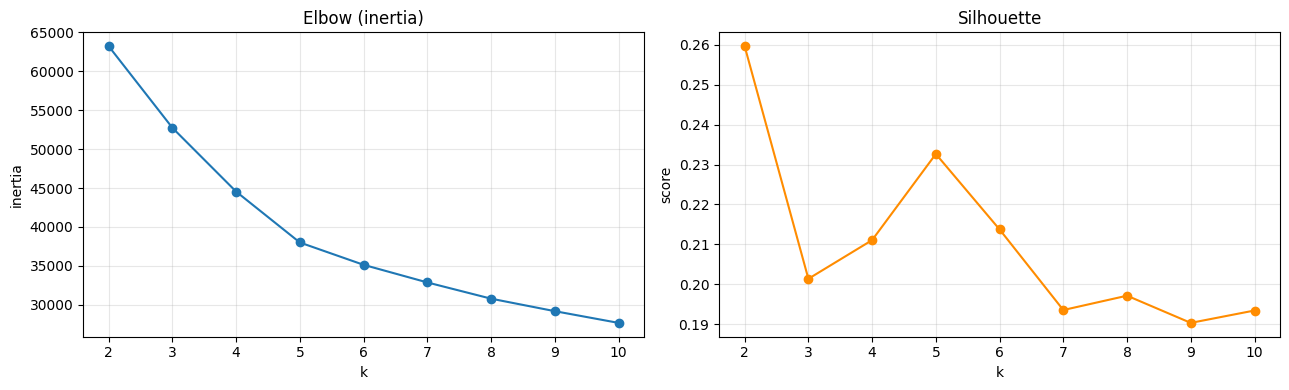

Best k by silhouette = 2 (score=0.260)


In [6]:
X_animal, _ = scale_features(df_animal, animal_feats)
kmeans_diagnostics(X_animal, k_range=range(2, 41))   # wide sweep: read the elbow knee

# >>> SET THE NUMBER OF CLUSTERS YOU WANT HERE <<<
best_k_animal = 4

K-Means k=4 | silhouette=0.212


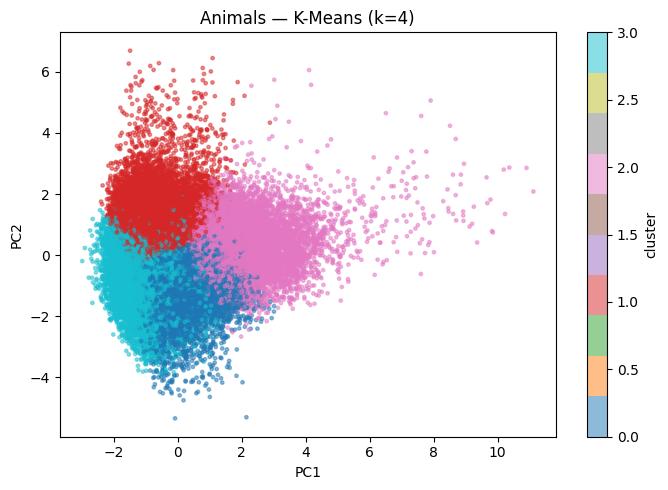

,milk_kg,DIM,parity,AFC,size
cluster,,,,,
0,11.138,137.865,3.060,"1,061.694",24730
1,7.884,162.554,2.052,"1,079.503",25399
2,9.119,136.868,5.956,"1,471.095",17175
3,8.190,103.628,1.798,"1,082.577",23917


In [7]:
labels_km = run_kmeans(X_animal, best_k_animal)
pca_scatter(X_animal, labels_km, f'Animals — K-Means (k={best_k_animal})')
profile_clusters(df_animal, labels_km, animal_feats)

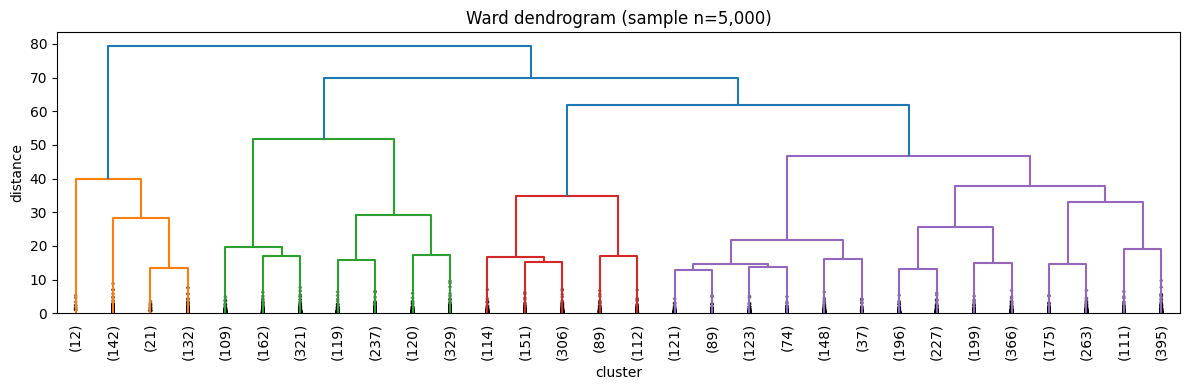

Hierarchical k=4 | silhouette=0.163 (on sample)


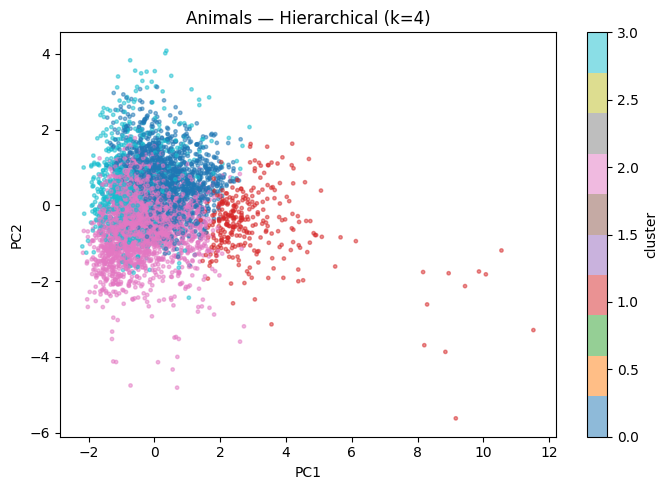

,milk_kg,DIM,parity,AFC,size
cluster,,,,,
0,10.552,136.517,4.328,"1,078.211",1397
1,8.995,136.271,6.906,"1,877.518",307
2,8.399,147.948,2.236,"1,118.520",2524
3,8.251,92.999,1.665,"1,122.745",772


In [8]:
idx_h, labels_h = run_hierarchical(X_animal, best_k_animal)
pca_scatter(X_animal[idx_h], labels_h, f'Animals — Hierarchical (k={best_k_animal})')
profile_clusters(df_animal.iloc[idx_h], labels_h, animal_feats)

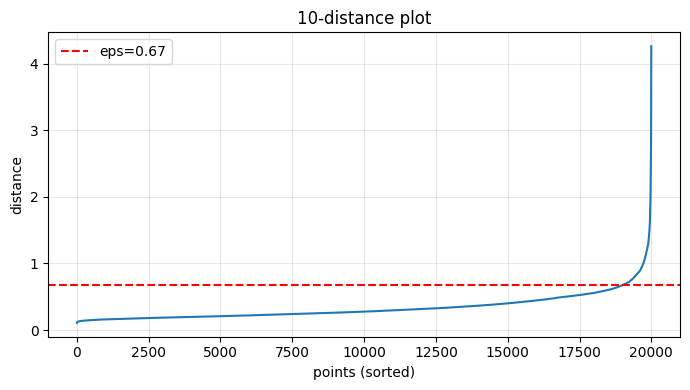

DBSCAN eps=0.67, min_samples=10 | clusters=1, noise=2.4%


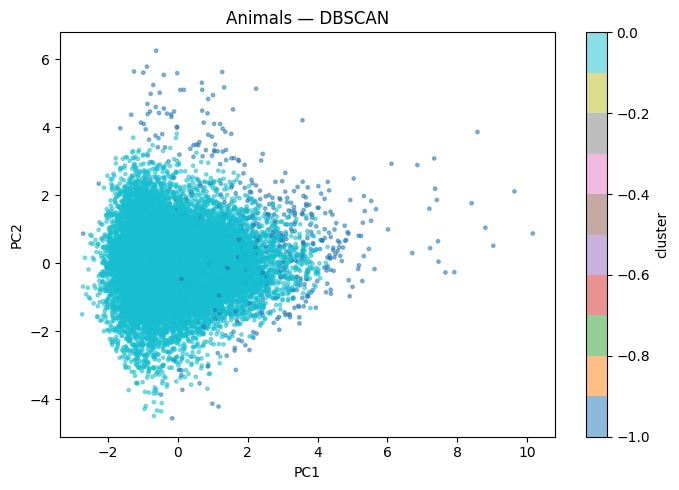

,milk_kg,DIM,parity,AFC,size
cluster,,,,,
-1,8.783,155.212,5.002,"1,961.792",475
0,9.083,135.037,2.966,"1,132.550",19525


In [9]:
# DBSCAN on CONTINUOUS traits only. parity is an integer and AFC tracks it,
# so including them made DBSCAN slice by parity band instead of by milk/DIM density.
dbscan_feats = ['milk_kg', 'DIM']
X_animal_dbs, _ = scale_features(df_animal, dbscan_feats)
idx_d, labels_d = run_dbscan(X_animal_dbs)
pca_scatter(X_animal_dbs[idx_d], labels_d, 'Animals - DBSCAN (milk_kg, DIM)')
profile_clusters(df_animal.iloc[idx_d], labels_d, animal_feats)

## Level 2 — Per lactation

Group `(Animal_ID, parity)` lactations by their summary curve.

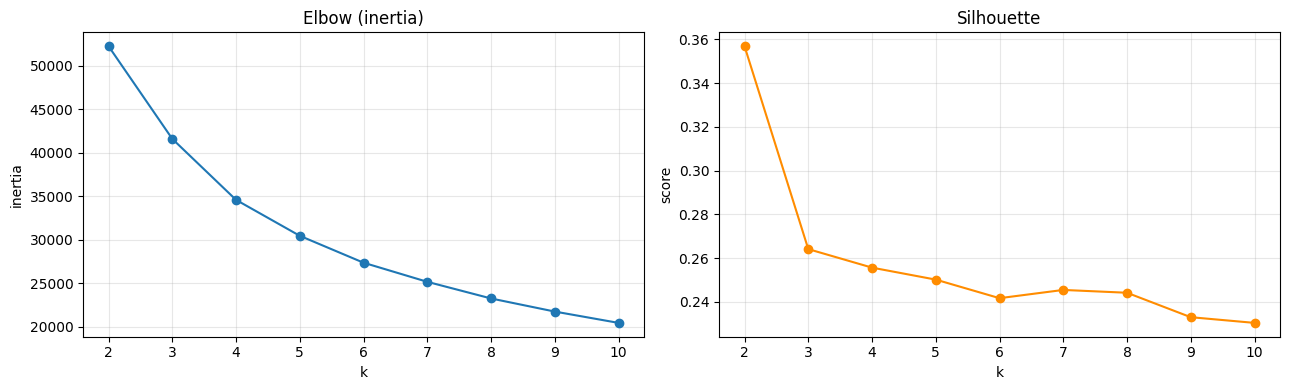

Best k by silhouette = 2 (score=0.357)


In [10]:
X_lact, _ = scale_features(df_lact, lact_feats)
kmeans_diagnostics(X_lact, k_range=range(2, 41))   # wide sweep: read the elbow knee

# >>> SET THE NUMBER OF CLUSTERS YOU WANT HERE <<<
best_k_lact = 4

K-Means k=4 | silhouette=0.257


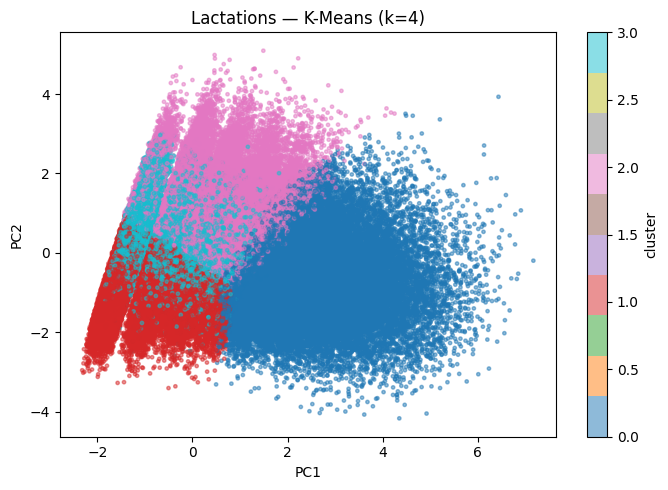

,milk_kg,DIM_max,parity,AFC,size
cluster,,,,,
0,9.144,230.321,5.890,"3,273.477",45969
1,8.497,300.077,1.623,"1,354.076",76983
2,11.940,220.914,2.800,"1,869.208",60712
3,8.099,187.094,1.870,"1,445.169",63581


In [11]:
labels_km = run_kmeans(X_lact, best_k_lact)
pca_scatter(X_lact, labels_km, f'Lactations — K-Means (k={best_k_lact})')
profile_clusters(df_lact, labels_km, lact_feats)

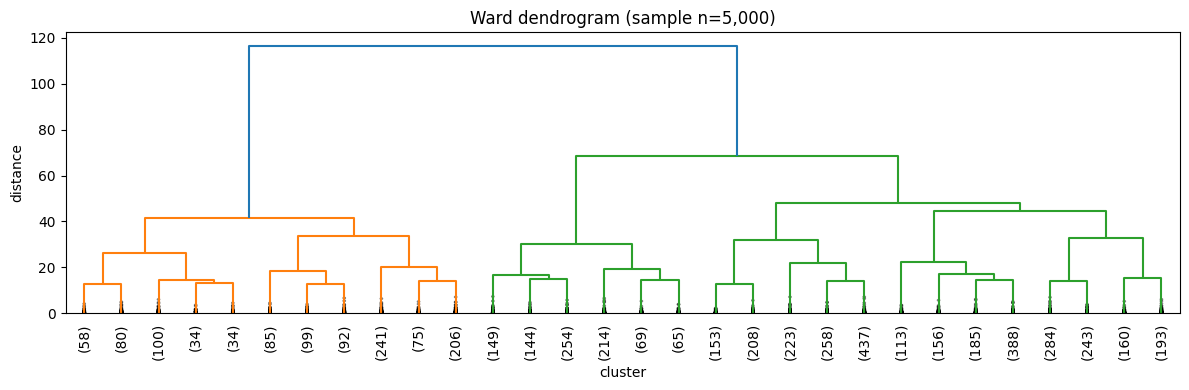

Hierarchical k=4 | silhouette=0.183 (on sample)


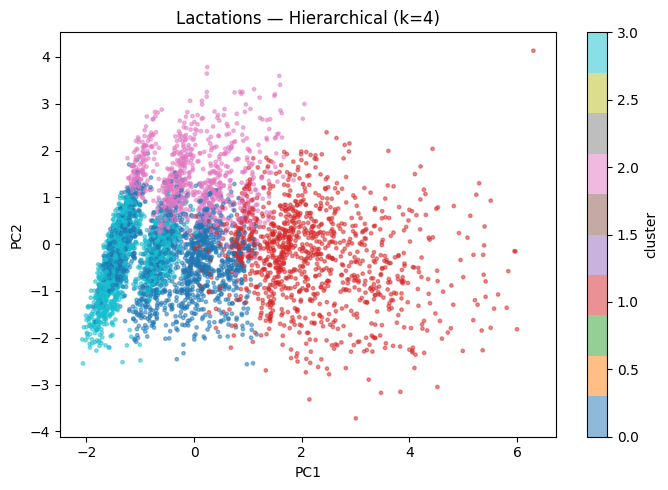

,milk_kg,DIM_max,parity,AFC,size
cluster,,,,,
0,7.938,231.472,2.199,"1,615.335",1722
1,9.495,222.447,5.691,"3,179.495",1104
2,11.894,194.620,2.431,"1,701.027",895
3,9.180,289.848,1.310,"1,205.904",1279


In [12]:
idx_h, labels_h = run_hierarchical(X_lact, best_k_lact)
pca_scatter(X_lact[idx_h], labels_h, f'Lactations — Hierarchical (k={best_k_lact})')
profile_clusters(df_lact.iloc[idx_h], labels_h, lact_feats)

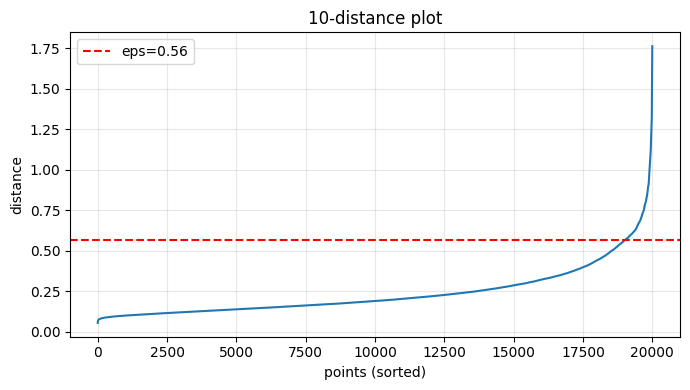

DBSCAN eps=0.56, min_samples=10 | clusters=1, noise=2.1%


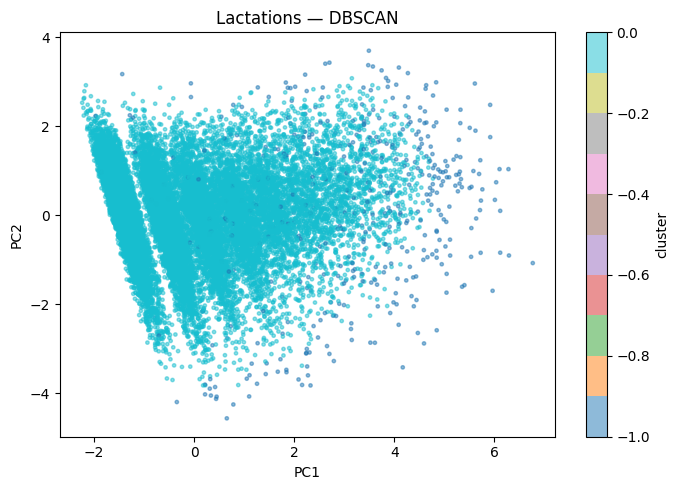

,milk_kg,DIM_max,parity,AFC,size
cluster,,,,,
-1,9.768,192.595,6.762,"3,799.304",425
0,9.351,239.432,2.691,"1,821.832",19575


In [13]:
# DBSCAN on CONTINUOUS traits only (see note in the per-animal DBSCAN cell).
dbscan_feats = ['milk_kg', 'DIM_max']
X_lact_dbs, _ = scale_features(df_lact, dbscan_feats)
idx_d, labels_d = run_dbscan(X_lact_dbs)
pca_scatter(X_lact_dbs[idx_d], labels_d, 'Lactations - DBSCAN (milk_kg, DIM_max)')
profile_clusters(df_lact.iloc[idx_d], labels_d, lact_feats)

## Level 3 — Per test-day record

The full table has ~1.6M rows. K-Means runs on all rows; diagnostics, hierarchical and DBSCAN run on a random sample for tractability.

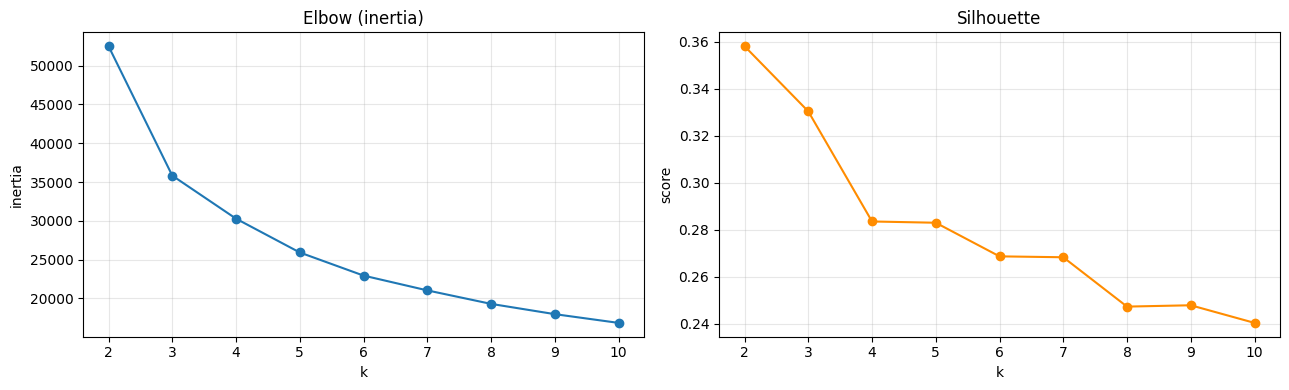

Best k by silhouette = 2 (score=0.358)


In [14]:
X_record, _ = scale_features(df_record, record_feats)
kmeans_diagnostics(X_record, k_range=range(2, 41))   # wide sweep: read the elbow knee

# >>> SET THE NUMBER OF CLUSTERS YOU WANT HERE <<<
best_k_record = 4

K-Means k=4 | silhouette=0.285


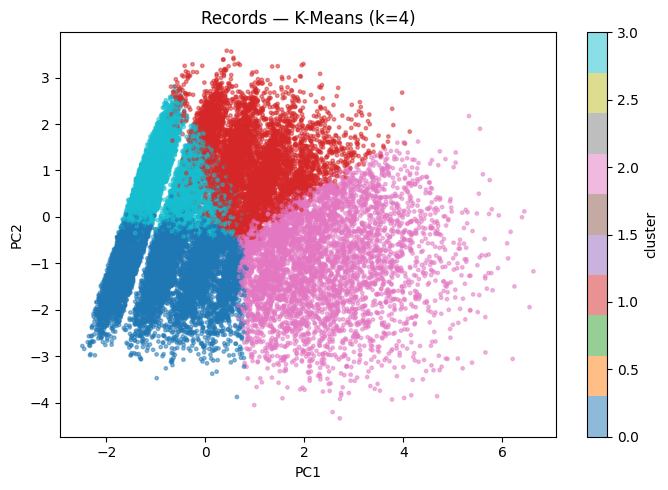

,milk_kg,DIM,parity,AFC,size
cluster,,,,,
0,6.542,228.915,1.979,"1,513.382",527639
1,13.549,77.488,3.276,"2,104.046",344231
2,8.504,147.388,6.031,"3,339.184",258500
3,9.823,90.176,1.447,"1,253.163",515513


In [15]:
labels_km = run_kmeans(X_record, best_k_record)
# PCA scatter on a sample to keep the plot readable
samp = np.random.choice(len(X_record), 30000, replace=False)
pca_scatter(X_record[samp], labels_km[samp], f'Records — K-Means (k={best_k_record})')
profile_clusters(df_record, labels_km, record_feats)

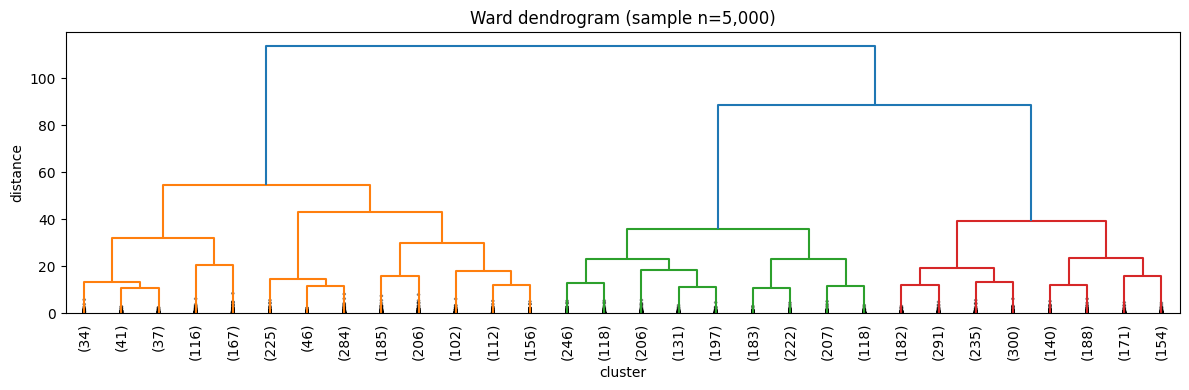

Hierarchical k=4 | silhouette=0.278 (on sample)


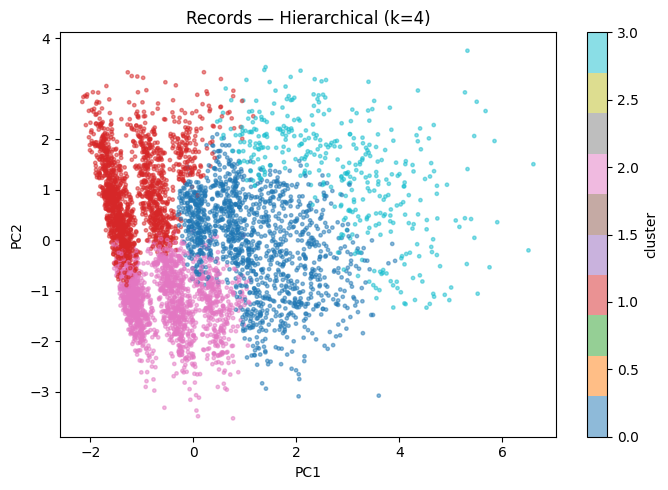

,milk_kg,DIM,parity,AFC,size
cluster,,,,,
0,10.112,128.169,4.274,"2,547.582",1316
1,6.798,213.337,1.539,"1,317.913",1661
2,11.632,68.793,1.838,"1,440.875",1628
3,7.089,180.937,6.899,"3,688.754",395


In [16]:
idx_h, labels_h = run_hierarchical(X_record, best_k_record)
pca_scatter(X_record[idx_h], labels_h, f'Records — Hierarchical (k={best_k_record})')
profile_clusters(df_record.iloc[idx_h], labels_h, record_feats)

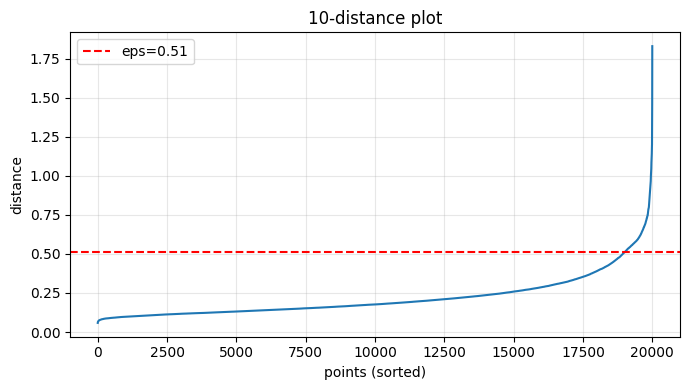

DBSCAN eps=0.51, min_samples=10 | clusters=11, noise=2.1%


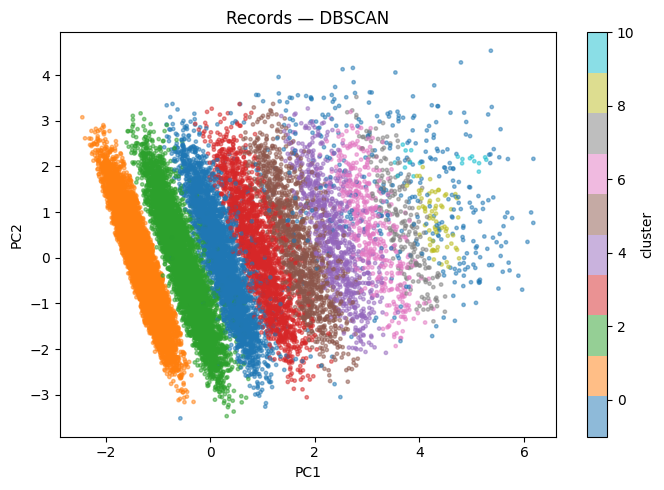

,milk_kg,DIM,parity,AFC,size
cluster,,,,,
-1,8.495,162.575,7.061,"3,924.299",428
0,9.767,138.121,3.000,"1,993.971",3178
1,8.563,146.583,1.000,"1,059.821",6527
2,9.695,141.719,2.000,"1,541.721",4848
3,9.811,134.450,4.000,"2,407.256",2053
4,9.659,125.111,6.000,"3,263.327",836
5,9.880,132.478,5.000,"2,854.076",1338
6,9.703,128.489,7.000,"3,701.478",481
7,9.661,126.333,8.000,"3,960.644",222


In [17]:
# DBSCAN on CONTINUOUS traits only (see note in the per-animal DBSCAN cell).
dbscan_feats = ['milk_kg', 'DIM']
X_record_dbs, _ = scale_features(df_record, dbscan_feats)
idx_d, labels_d = run_dbscan(X_record_dbs)
pca_scatter(X_record_dbs[idx_d], labels_d, 'Records - DBSCAN (milk_kg, DIM)')
profile_clusters(df_record.iloc[idx_d], labels_d, record_feats)

## Notes

- `best_k` is chosen by maximum silhouette; inspect the elbow plot and override manually if a different `k` is more interpretable for the thesis.
- DBSCAN `eps` is set at the 95th percentile of the k-distance curve as a starting heuristic — tune `eps` / `min_samples` per level if noise is too high or everything collapses into one cluster.
- Hierarchical and DBSCAN use random samples; set the same `RANDOM_STATE` to reproduce, or raise the `sample=` argument if memory allows.